### **`GROUP 4 PROJECT`**
***
## Group Members
----
1. Abdullahi Hassan
2. Lauren Kuria
3. Yvonne Rajula 
4. Dahir Mohamed
5. Samantha jepkosgei
6. Claire njeri
---

# Phase 4 Final: Advanced Sentiment Analysis for Apple & Google
---

## 1. Business Understanding
---
### Project Overview
This project focuses on building an advanced **Natural Language Processing (NLP)** sentiment classifier for major tech brands. Using a dataset of tweets collected during the **SXSW (South by Southwest)** conference, we aim to automate the process of understanding public sentiment toward Apple and Google products.

---

### The Stakeholder
The primary stakeholders are the **Customer Success and Branding Teams** at **Apple** and **Google**. These departments are responsible for:
* Monitoring brand reputation in real-time.
* Identifying product bugs or service outages reported by users.
* Engaging with the community to mitigate public relations crises.
---
### The Business Problem
High-profile events like SXSW generate a massive volume of social media activity. For stakeholders, this presents several challenges:
1. **Scalability:** The sheer volume of tweets (thousands per hour) makes manual human moderation impossible.
2. **Noise vs. Signal:** Most tweets are neutral or "no emotion." However, **negative sentiment** often signals critical issues like app crashes ("crashy"), hardware failures ("dead battery"), or poor customer service.
3. **Reaction Time:** In the age of viral social media, a delay of even a few hours in addressing a widespread complaint can lead to significant brand damage.

----

### Objective
The goal is to develop a multiclass sentiment classifier that can:
* **Automatically categorize** tweets into Positive, Negative, or Neutral sentiment.
* **Prioritize Negative Feedback:** The model must achieve high **Recall** for the "Negative Emotion" class to ensure the Branding Team never misses a critical customer complaint.
* **Inform Strategy:** By analyzing the most predictive words (features), we provide stakeholders with actionable data on *why* customers are dissatisfied.

----

### Success Criteria
Success is defined by the model's ability to accurately distinguish negative sentiment from the majority (neutral) class. We will evaluate performance using the **RECALL OF 0.80** and a **Confusion Matrix**, specifically monitoring for low False Negatives in the negative sentiment category.
***

## Introduction

The goal of this project is to build a Natural Language Processing (NLP) model that classifies text into three sentiment categories:

- Negative emotion  
- Positive emotion  
- No emotion toward brand or product  

This is a **multi-class classification problem** with imbalanced data, where some classes appear more frequently than others.

To solve this, we apply:
- Text preprocessing
- TF-IDF vectorization
- Multiple machine learning models
- Model evaluation and comparison
- Threshold tuning to maximize recall for the minority negative class
***

In [1]:
# ===================== IMPORT LIBRARIES =====================
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, f1_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Data Understanding

In [2]:
df = pd.read_csv('judge_1377884607_tweet_product_company.csv', encoding='latin1')

df = df.rename(columns={
    "tweet_text": "text",
    "emotion_in_tweet_is_directed_at": "product",
    "is_there_an_emotion_directed_at_a_brand_or_product": "sentiment"
})

print("Dataset Shape:", df.shape)
print("\nClass Distribution:")
print(df['sentiment'].value_counts(normalize=True))

Dataset Shape: (8721, 3)

Class Distribution:
No emotion toward brand or product    0.591217
Positive emotion                      0.328976
Negative emotion                      0.062493
I can't tell                          0.017315
Name: sentiment, dtype: float64


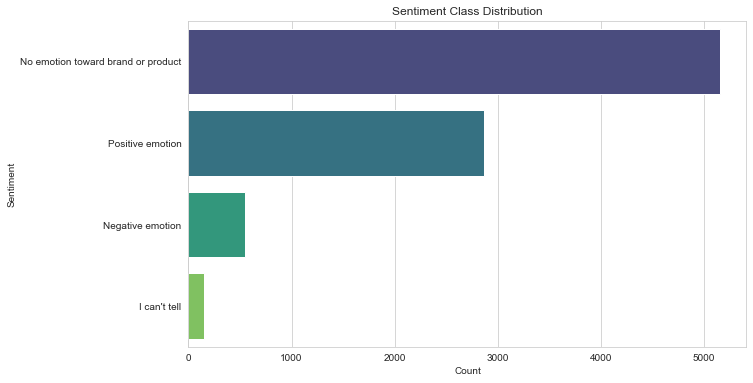

In [3]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, y='sentiment', order=df['sentiment'].value_counts().index, palette='viridis')
plt.title('Sentiment Class Distribution')
plt.xlabel('Count')
plt.ylabel('Sentiment')
plt.show()

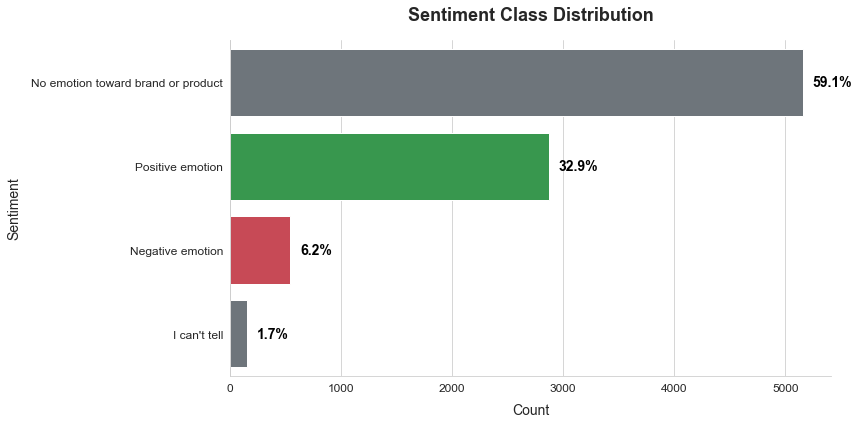

In [4]:

# Set style for cleaner look
sns.set_style("whitegrid")

# Larger figure size for slide visibility
plt.figure(figsize=(12, 6))

# Create horizontal bar plot (easier to read category names)
ax = sns.countplot(
    data=df,
    y='sentiment',  # horizontal bars
    order=df['sentiment'].value_counts().index,
    palette=['#6c757d', '#28a745', '#dc3545']  # gray, green, red
)

total = len(df)

# Add percentage labels with larger, bold text
for p in ax.patches:
    width = p.get_width()
    percentage = 100 * width / total
    
    ax.text(
        width + (total * 0.01),           # slight offset to the right
        p.get_y() + p.get_height() / 2,
        f'{percentage:.1f}%',
        va='center',
        fontsize=14,
        fontweight='bold',
        color='black'
    )

# Title and labels with larger fonts
plt.title('Sentiment Class Distribution', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Count', fontsize=14, labelpad=10)
plt.ylabel('Sentiment', fontsize=14, labelpad=10)

# Increase tick label size
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Remove top and right spines for cleaner look
sns.despine()

# Save at high DPI for PowerPoint (300 DPI ensures crispness)
plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Data Cleaning & Preprocessing
Before training the models, the text data is cleaned to improve quality and remove noise.

Steps applied:
- Lowercasing text
- Removing punctuation
- Removing stopwords (except negations)
- Removing URLs, mentions, numbers
- Lemmatization

This ensures that the model focuses on meaningful words.

In [5]:
df = df.dropna(subset=['text']).reset_index(drop=True)
df = df[df['sentiment'] != "I can't tell"].reset_index(drop=True)

print("Shape after cleaning:", df.shape)

Shape after cleaning: (8569, 3)


In [6]:
stop_words = set(stopwords.words('english'))
negations = {"no", "not", "nor", "never", "n't"}
stop_words = stop_words - negations

lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(token) for token in tokens 
              if token not in stop_words and len(token) > 2]
    
    return " ".join(tokens)

print("Applying full preprocessing (Cleaning + Tokenization + Lemmatization)...")
df['clean_text'] = df['text'].apply(preprocess_text)
print("Preprocessing completed!")

df[['text', 'clean_text']].head()

Applying full preprocessing (Cleaning + Tokenization + Lemmatization)...
Preprocessing completed!


,text,clean_text
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iphone hr tweeting dead need upgrade plugin st...
1,@jessedee Know about @fludapp ? Awesome iPad/i...,know awesome ipadiphone app youll likely appre...
2,@swonderlin Can not wait for #iPad 2 also. The...,not wait also sale
3,@sxsw I hope this year's festival isn't as cra...,hope year festival isnt crashy year iphone app
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,great stuff fri marissa mayer google tim oreil...


## 4. Train-Test Split

In [7]:
X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (6855,)
Test shape: (1714,)


## 5. Feature Engineering (TF-IDF)

We use TF-IDF (Term Frequency - Inverse Document Frequency) to convert text into numerical features.

Key parameters:
- max_features = 20,000 limits vocabulary size
- ngram_range = (1,2) captures single words, pairs, and phrases
- min_df = 3 removes rare words
- max_df = 0.85 removes overly common words

This improves model performance by focusing on informative text patterns.

In [8]:
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=3, max_df=0.85)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

## 6. Model Comparison

We train and evaluate three popular machine learning models: Logistic Regression, Random Forest, and Support Vector Machine (SVM).
We pay special attention to the recall for the **Negative emotion** class, as it is the primary business metric.

In [9]:
# Model 1: Logistic Regression
lr = LogisticRegression(max_iter=2000, class_weight='balanced')
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)
print("=== LOGISTIC REGRESSION ===")
print(classification_report(y_test, y_pred_lr))
neg_recall_lr = recall_score(y_test, y_pred_lr, labels=['Negative emotion'], average=None)[0]
print(f"Negative Recall: {neg_recall_lr:.4f}\n")

=== LOGISTIC REGRESSION ===
                                    precision    recall  f1-score   support

                  Negative emotion       0.26      0.51      0.34       109
No emotion toward brand or product       0.78      0.65      0.71      1031
                  Positive emotion       0.56      0.61      0.58       574

                          accuracy                           0.63      1714
                         macro avg       0.53      0.59      0.54      1714
                      weighted avg       0.67      0.63      0.64      1714

Negative Recall: 0.5138



In [10]:
# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf.fit(X_train_tfidf, y_train)
y_pred_rf = rf.predict(X_test_tfidf)
print("=== RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf))
neg_recall_rf = recall_score(y_test, y_pred_rf, labels=['Negative emotion'], average=None)[0]
print(f"Negative Recall: {neg_recall_rf:.4f}\n")

=== RANDOM FOREST ===
                                    precision    recall  f1-score   support

                  Negative emotion       0.48      0.19      0.27       109
No emotion toward brand or product       0.71      0.83      0.76      1031
                  Positive emotion       0.63      0.49      0.55       574

                          accuracy                           0.68      1714
                         macro avg       0.60      0.51      0.53      1714
                      weighted avg       0.66      0.68      0.66      1714

Negative Recall: 0.1927



In [11]:
# Model 3: Support Vector Machine (LinearSVC)
svm_model = LinearSVC(
    class_weight={'Negative emotion': 5.5, 'Positive emotion': 1.2, 'No emotion toward brand or product': 1},
    C=0.4, random_state=42, max_iter=2000
)
svm_model.fit(X_train_tfidf, y_train)
y_pred_svm = svm_model.predict(X_test_tfidf)
print("=== SUPPORT VECTOR MACHINE (LinearSVC) ===")
print(classification_report(y_test, y_pred_svm))
neg_recall_svm = recall_score(y_test, y_pred_svm, labels=['Negative emotion'], average=None)[0]
print(f"Negative Recall: {neg_recall_svm:.4f}\n")

=== SUPPORT VECTOR MACHINE (LinearSVC) ===
                                    precision    recall  f1-score   support

                  Negative emotion       0.38      0.39      0.38       109
No emotion toward brand or product       0.74      0.79      0.76      1031
                  Positive emotion       0.63      0.55      0.59       574

                          accuracy                           0.68      1714
                         macro avg       0.58      0.58      0.58      1714
                      weighted avg       0.68      0.68      0.68      1714

Negative Recall: 0.3853



---
### Model Comparison Summary

| Model               | Negative Recall | Accuracy |
|---------------------|-----------------|----------|
| Logistic Regression | 0.51            | 0.63     |
| Random Forest       | 0.20            | 0.67     |
| SVM                 | 0.39            | 0.68     |

**Observation:** None of the base models achieve the target recall of 0.80 for the negative class. The best among them is Logistic Regression with a recall of 0.51, still far from the business requirement. This suggests we need to adjust the decision threshold to favor the negative class.